In [1]:
from functools import reduce

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
# with open(r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\correct.bin', 'rb') as f:
#     ans_df = pickle.load(file=f)
#     ans_df = ans_df[ans_df['task'] != 'SIQA']

# ans_df.head()

In [19]:
# preds_path_ls = [
#     ('Raw',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\Raw-CR.bin'),
#     ('LoRA',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA-cfg18-CR.bin'),
#     ('LoRA 1b',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA_1b-cfg1-CR.bin'),
#     ('DoRA',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\DoRA-cfg18-CR.bin'),
#     ('VeRA',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\VeRA-cfg1-CR.bin'),
#     ('GSOFT',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\GSOFT-cfg3-CR.bin'),
# ]

LoRA_cfg = 3
GSOFT_cfg = 13

preds_path_ls = [
    ('Raw_1b',  r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\Raw_1b_CR.bin'),
    ('LoRA_1b-CR',  rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA_1b-cfg{LoRA_cfg}-CR_CR.bin'),
    ('GSOFT_1b-CR',  rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\GSOFT_1b-cfg{GSOFT_cfg}-CR_CR.bin'),
]

max_step = 8_000
for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'LoRA_1b-code st-{st}', rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\LoRA_1b-cfg{LoRA_cfg}-st{st}_CR.bin')
    )

for st in range(2_000, max_step+1, 2_000):
    preds_path_ls.append(
        (f'GSOFT_1b-code st-{st}', rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\val_preds\GSOFT_1b-cfg{GSOFT_cfg}-st{st}_CR.bin')
    )

In [20]:
preds_dfs = []

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_df: pd.DataFrame = pickle.load(file=f)
        preds_df.insert(loc=len(preds_df.columns), column='run_name', value=run_name)

        preds_dfs.append(preds_df)

In [21]:
preds_df = pd.concat(preds_dfs)

preds_df.head()

,text,text_wa_answer,correct_answer,task,model_pred,run_name
0,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,False,BoolQ,{'generated_text': ': False'},Raw_1b
1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': False'},Raw_1b
2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': False'},Raw_1b
3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': TRUE'},Raw_1b
4,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,{'generated_text': ': True'},Raw_1b


In [22]:
preds_df[['task', 'correct_answer']].value_counts().sort_index()

task        correct_answer
ARC-C       1                     8
            2                     4
            4                     4
            A                   248
            B                   288
            C                   312
            D                   328
            E                     4
ARC-E       1                    24
            2                    28
            3                    20
            4                    12
            A                   608
            B                   580
            C                   548
            D                   460
BoolQ       False              4948
            True               8132
OBQA        A                   504
            B                   552
            C                   440
            D                   504
PIQA        Solution1          3640
            Solution2          3712
SIQA        A                  2572
            B                  2616
            C                  2628
h

In [23]:
sorted(list(preds_df['correct_answer'].unique()))

['1',
 '2',
 '3',
 '4',
 'A',
 'B',
 'C',
 'D',
 'E',
 'Ending0',
 'Ending1',
 'Ending2',
 'Ending3',
 'False',
 'Option1',
 'Option2',
 'Solution1',
 'Solution2',
 'True']

In [24]:
preds_df['run_name'].value_counts()

run_name
Raw_1b             19740
LoRA_1b-CR         19740
GSOFT_1b-CR        19740
GSOFT_1b-CR TMP    19740
Name: count, dtype: int64

In [25]:
tasks = preds_df.task.unique()

tasks

array(['BoolQ', 'PIQA', 'SIQA', 'hellaswag', 'winogrande', 'ARC-E',
       'ARC-C', 'OBQA'], dtype=object)

In [26]:
import string
import re

punct_trans = str.maketrans(dict.fromkeys(string.punctuation))

def BoolQ_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

def SIQA_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

PIQA_pattern = re.compile('Solution[1,2]')
def PIQA_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip() if pred else ''
    pred = re.match(PIQA_pattern, pred)
    pred = pred.group(0) if pred else 'None'

    return pred

hellaswag_pattern = re.compile('(Ending)?[0,1,2,3]')
def hellaswag_process(pred):
    pred = pred['generated_text']
    pred_0 = pred

    pred = pred.translate(punct_trans).strip()
    pred = pred.split()[0] if pred else ''
    pred = re.match(hellaswag_pattern, pred)
    if pred:
        pred = pred.group(0)
        pred = f'Ending{pred[-1]}'
    else:
        pred = pred_0

    return pred

winogrande_pattern = re.compile('Option[1,2]')
def winogrande_process(pred):
    pred = pred['generated_text']
    pred_0 = pred

    pred = pred.translate(punct_trans).strip()
    pred = pred.split()[0] if pred else ''
    pred = re.match(winogrande_pattern, pred)
    if pred:
        pred = pred.group(0)
        pred = f'Option{pred[-1]}'
    else:
        pred = pred_0

    return pred

def ARC_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

def OBQA_process(pred):
    pred = pred['generated_text'].strip()
    pred = pred.translate(punct_trans)
    pred = pred.split()[0].strip()

    return pred

In [27]:
preds_dfs[0][preds_dfs[0]['task'] == 'SIQA']['model_pred'].apply(SIQA_process)

5108    B
5109    A
5110    A
5111    A
5112    A
       ..
7057    C
7058    B
7059    C
7060    B
7061    B
Name: model_pred, Length: 1954, dtype: object

In [28]:
preds_dfs[0][preds_dfs[0]['task'] == 'SIQA']['correct_answer'][5108]

'C'

In [29]:
task_postprocessors = {
    'BoolQ': BoolQ_process,
    'PIQA': PIQA_process,
    'SIQA': SIQA_process,
    'hellaswag': hellaswag_process,
    'winogrande': winogrande_process,
    'ARC-E': ARC_process,
    'ARC-C': ARC_process,
    'OBQA': OBQA_process
}

for task, processor in task_postprocessors.items():
    preds_df.loc[preds_df['task'] == task, 'model_pred'] = preds_df.loc[preds_df['task'] == task, 'model_pred'].apply(processor)

preds_df.head()

,text,text_wa_answer,correct_answer,task,model_pred,run_name
0,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,False,BoolQ,False,Raw_1b
1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b
2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b
3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,TRUE,Raw_1b
4,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,True,Raw_1b


In [30]:
preds_df.loc[:, 'is_correct'] = (preds_df.loc[:, 'correct_answer'] == preds_df.loc[:, 'model_pred'])

preds_df.head()

,text,text_wa_answer,correct_answer,task,model_pred,run_name,is_correct
0,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,False,BoolQ,False,Raw_1b,True
1,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b,False
2,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,False,Raw_1b,False
3,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,TRUE,Raw_1b,False
4,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,True,BoolQ,True,Raw_1b,True


In [31]:
accuracy = preds_df[['run_name', 'task', 'is_correct']].groupby(by=['run_name', 'task'], as_index=False)['is_correct'].mean()

accuracy

,run_name,task,is_correct
0,GSOFT_1b-CR,ARC-C,0.515050
1,GSOFT_1b-CR,ARC-E,0.705263
2,GSOFT_1b-CR,BoolQ,0.631193
3,GSOFT_1b-CR,OBQA,0.638000
4,GSOFT_1b-CR,PIQA,0.707291
5,GSOFT_1b-CR,SIQA,0.642784
6,GSOFT_1b-CR,hellaswag,0.646485
7,GSOFT_1b-CR,winogrande,0.527230
8,GSOFT_1b-CR TMP,ARC-C,0.525084
9,GSOFT_1b-CR TMP,ARC-E,0.705263


In [32]:
accuracy[accuracy['run_name'] == 'GSOFT']

,run_name,task,is_correct


In [33]:
total_res = accuracy[['run_name', 'is_correct']].groupby(by=['run_name'], as_index=False).mean()

total_res

,run_name,is_correct
0,GSOFT_1b-CR,0.626662
1,GSOFT_1b-CR TMP,0.634351
2,LoRA_1b-CR,0.414279
3,Raw_1b,0.460116


In [18]:
total_res[total_res['run_name'] == 'Raw_1b'].is_correct.iloc[-1]

0.4601163345574698

Text(0, 0.5, 'CR mean accuracy')

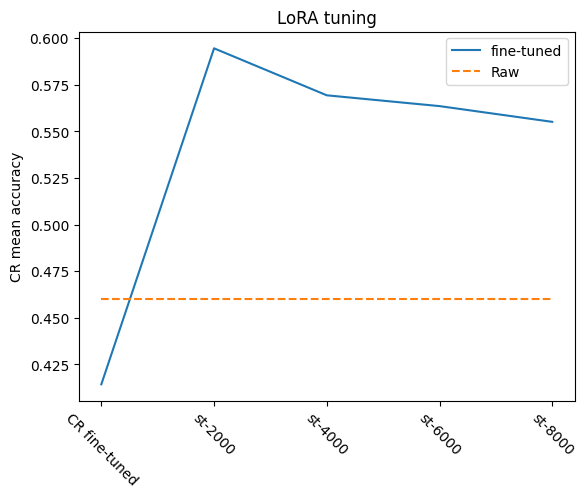

In [19]:
scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].is_correct.iloc[-1]]
scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].is_correct.iloc[-1]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw_1b'].is_correct.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('CR mean accuracy')

Text(0, 0.5, 'CR mean accuracy')

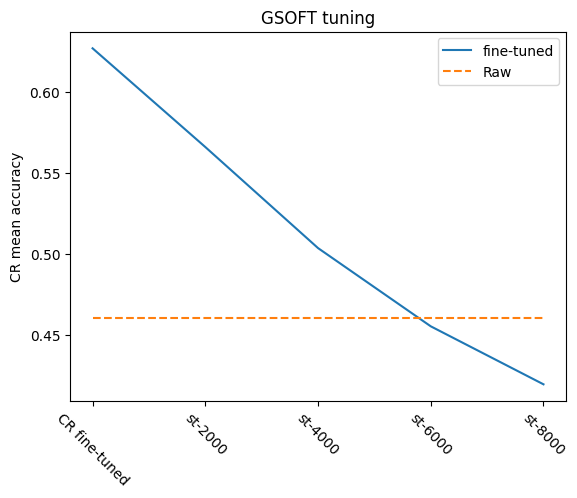

In [20]:
scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].is_correct.iloc[-1]]
scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].is_correct.iloc[-1]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=scores,
    label='fine-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw_1b'].is_correct.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('GSOFT tuning')
plt.ylabel('CR mean accuracy')

Text(0, 0.5, 'CR mean accuracy')

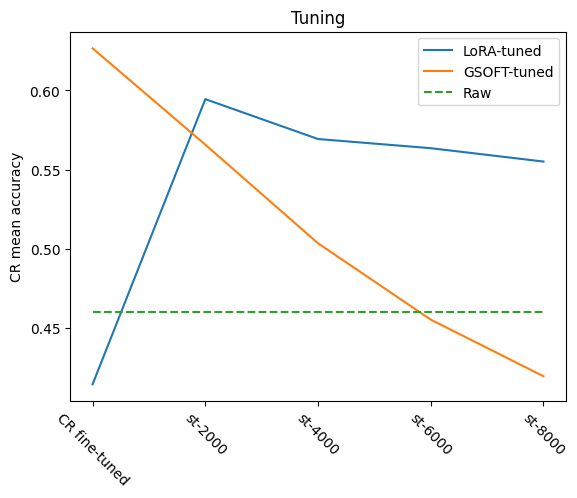

In [21]:
LoRA_scores = [total_res[total_res['run_name'] == 'LoRA_1b-CR'].is_correct.iloc[-1]]
LoRA_scores += [
    total_res[total_res['run_name'] == f'LoRA_1b-code st-{st}'].is_correct.iloc[-1]
    for st in range(2000, max_step+1,2000)
]

GSOFT_scores = [total_res[total_res['run_name'] == 'GSOFT_1b-CR'].is_correct.iloc[-1]]
GSOFT_scores += [
    total_res[total_res['run_name'] == f'GSOFT_1b-code st-{st}'].is_correct.iloc[-1]
    for st in range(2000, max_step+1,2000)
]

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=LoRA_scores,
    label='LoRA-tuned'
)

sns.lineplot(
    x=range(0, max_step+1, 2000),
    y=GSOFT_scores,
    label='GSOFT-tuned'
)

sns.lineplot(
    x=[0, max_step],
    y=[total_res[total_res['run_name'] == 'Raw_1b'].is_correct.iloc[-1]] * 2,
    linestyle='--',
    label='Raw'
)

plt.xticks(
    range(0, max_step+1,2000),
    labels=['CR fine-tuned'] + [f'st-{st}' for st in range(2000, max_step+1,2000)],
    rotation=-45
)

plt.title('Tuning')
plt.ylabel('CR mean accuracy')